# Tests to compare everything with each other

## Verglecih der biophysikalischen Merkmale von CDR-H3, H2 und H3 zwischen den einzlennen Spezien 

- ANOVO:
    - Prüft, ob es einen signifikanten Unterschied im Mittelwert der Eigenschaft zwischen den drei Gruppen gibt

!! ANOVA sagt nicht, wo genau der Unterschied liegt – nur, ob überhaupt einer da ist

     => Gibt den p-Wert aus dem ANOVA-Test aus
     
→ Ein Wert kleiner als 0.05 gilt oft als signifikant


## Erklärung Code für ANOVA Test:

##  Zeile 1

```python
import pandas as pd
```

* `import`: holt ein externes Modul in dein Python-Skript.
* `pandas`: eine sehr verbreitete Bibliothek zur Datenanalyse und Tabellenverarbeitung.
* `as pd`: wir geben `pandas` den Kurznamen `pd`, damit wir später schneller darauf zugreifen können.

> Ab jetzt verwenden wir `pd` immer, wenn wir `pandas`-Funktionen benutzen (z. B. `pd.read_csv`, `pd.DataFrame` usw.).

---

##  Zeile 2

```python
from scipy.stats import f_oneway
```

* `from scipy.stats`: importiert ein Untermodul der `scipy`-Bibliothek, nämlich das Statistikmodul.
* `f_oneway`: ist die Funktion für den **einseitigen Varianzanalysentest (ANOVA)**.
  Sie vergleicht **mehr als zwei Gruppen** auf Mittelwertsunterschiede.

>  Beispiel: Wenn du drei Gruppen hast (z. B. human, sars, influenza), prüft `f_oneway`, ob mindestens eine davon signifikant anders ist als die anderen.

---

##  Zeile 5

```python
df = pd.read_csv("all_data.tsv", sep="\t")
```

* `df`: der Name der DataFrame-Variable, also der Tabelle mit den Daten.
* `pd.read_csv`: liest eine Datei im CSV/TSV-Format ein.
* `"all_data.tsv"`: der Dateiname. Das ist eine **Tabulator-separierte** Datei (TSV = Tab-Separated Values).
* `sep="\t"`: gibt an, dass die Spalten **durch Tabulatoren** getrennt sind (`\t` = Tab-Zeichen).

>  Jetzt enthält `df` alle Spalten aus deiner Datei: wahrscheinlich Spalten wie `"source"`, `"CDR_H3_mean_mass"`, `"CDR_H3_mean_charge"` usw.

---

##  Zeile 8

```python
properties = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass'] 
```

* `properties`: eine Liste mit den Eigenschaften, die du analysieren möchtest.
* Diese Eigenschaften beziehen sich auf bestimmte chemisch-biologische Merkmale von Antikörpern (hier: CDR\_H3-Regionen).

>  Das Ziel ist, **jede dieser Eigenschaften** bei verschiedenen Herkunftsgruppen (human, sars\_cov2, influenza) zu vergleichen.

---

##  Zeile 11: Beginn der Schleife

```python
for prop in properties:
```

* `for`: startet eine Schleife.
* `prop`: eine temporäre Variable, die pro Schleifendurchlauf **ein Element** aus der Liste `properties` annimmt.
* Wir durchlaufen also: `mean_hydrophobicity`, `mean_charge`, `mean_polarity`, `mean_mass`.

>  Die Schleife wird **4× durchlaufen**, jeweils für eine dieser Eigenschaften.

---

##  Zeile 12

```python
column = f'CDR_H3_{prop}'
```

* `f'CDR_H3_{prop}'`: das ist ein sogenannter **f-String** (formatierter String).
* `{prop}` wird dynamisch durch den aktuellen Schleifenwert ersetzt.

  * z. B. in Durchlauf 1 → `"CDR_H3_mean_hydrophobicity"`
* Das ergibt den Spaltennamen, den wir in der Datei `df` suchen.

> Ziel: Zugriff auf die jeweilige Spalte mit Daten für eine bestimmte chemische Eigenschaft der CDR\_H3-Region.

---

##  Zeilen 14–16

```python
group_human = df[df["source"] == "human"][column].dropna()
group_sars = df[df["source"] == "sars_cov2"][column].dropna()
group_influenza = df[df["source"] == "influenza"][column].dropna()
```

Diese drei Zeilen extrahieren die Daten für jede Gruppe:

### Schrittweise Erklärung (für jede Zeile):

* `df["source"] == "human"`: erstellt eine **Maske** (True/False), die nur Zeilen mit `"source" == "human"` auswählt.
* `df[...]`: wendet diese Maske an → filtert nur die human-Zeilen.
* `[column]`: wählt dann aus diesen Zeilen **nur die relevante Spalte** (z. B. `"CDR_H3_mean_polarity"`).
* `.dropna()`: entfernt fehlende Werte (NaNs), damit die Statistik funktioniert.

>  Ergebnis: drei saubere Gruppen mit Werten zu z. B. `"CDR_H3_mean_charge"`.

---

## Zeile 18

```python
f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
```

* Hier rufen wir den **ANOVA-Test** auf.
* `f_oneway(...)`: testet, ob es **einen Unterschied im Mittelwert** zwischen den drei Gruppen gibt.
* Übergabe: `group_human`, `group_sars`, `group_influenza` (jeweils ein Array von Zahlen).
* Rückgabe:

  * `f_stat`: der berechnete F-Wert (wie viel größer die Streuung **zwischen** Gruppen im Vergleich zur Streuung **innerhalb** Gruppen ist).
  * `p_val`: der **p-Wert** – sagt, ob der Unterschied **statistisch signifikant** ist.

>  Wenn `p_val < 0.05`, dann ist mindestens eine Gruppe signifikant verschieden!

---

## Zeile 21

```python
print(f"{column} – ANOVA p-value: {p_val:.4f}")
```

* `print(...)`: zeigt das Ergebnis in der Konsole.
* `f"{column} – ANOVA p-value: {p_val:.4f}"`: ein formatierter String:

  * `{column}`: zeigt z. B. `"CDR_H3_mean_mass"`
  * `{p_val:.4f}`: formatiert den p-Wert auf **4 Nachkommastellen** (z. B. `0.0001`)

---




### CDR H3

### ANOVA

In [25]:
import pandas as pd
from scipy.stats import f_oneway # Function for the one-way analysis of variance test (ANOVA)

# Load the dataset
df = pd.read_csv("all_data.tsv", sep="\t")

# Properties to be analyzed
properties = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass'] # list of the properties we want to analyze

# Perform ANOVA test for each property
for prop in properties: # start loop 
    column = f'CDR_H3_{prop}'# f-String
    
    # Extract groups
    group_human = df[df["source"] == "human"][column].dropna()
    group_sars = df[df["source"] == "sars_cov2"][column].dropna()
    group_influenza = df[df["source"] == "influenza"][column].dropna()
    
    # ANOVA test
    f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
    
    # Print result
    print(f"{column} – ANOVA p-value: {p_val:.4f}")


CDR_H3_mean_hydrophobicity – ANOVA p-value: 0.4427
CDR_H3_mean_charge – ANOVA p-value: 0.0007
CDR_H3_mean_polarity – ANOVA p-value: 0.0006
CDR_H3_mean_mass – ANOVA p-value: 0.0000


### to be investigated further : 

#### - CDR_H3_mean_charge, 
#### - CDR_H3_mean_polarity, 
#### - CDR_H3_mean_mass
--------

## Erklärung Tukey HSD (Honest Significant Difference) Test Code 


```python
from statsmodels.stats.multicomp import pairwise_tukeyhsd
```

**Was passiert hier?**
Du importierst die Funktion `pairwise_tukeyhsd` aus dem Modul `statsmodels.stats.multicomp`.

Diese Funktion wird für den **Tukey-HSD-Test** verwendet – ein **post-hoc-Test**, der nach einer ANOVA prüft, **welche Gruppen sich signifikant unterscheiden**.

---

```python
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
```

Die Datei `all_data.tsv` wird mit **Tabulator-getrennten Werten** (`sep="\t"`) eingelesen.

---

```python
# Spalte für Analyse
column = 'CDR_H3_mean_polarity'
```

Du legst fest, **welche Variable** du untersuchen willst – hier ist es:


---

```python
# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()
```

Du erstellst eine neue Tabelle (`df_clean`) mit nur zwei Spalten:

1. Die **analysierte Eigenschaft** 
2. Die **Gruppierung** (`source`) – also: `human`, `sars_cov2`, `influenza`

Wichtig: Zeilen mit fehlenden Werten (`NaN`) werden entfernt → `dropna()`

---

```python
# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)
```


* `endog=` → die **Messwerte**, also die `CDR_H3_mean_polarity` pro Antikörper
* `groups=` → die **Kategorien**, nach denen gruppiert wird (`source`)
* `alpha=0.05` → Signifikanzniveau = 5 %


---

```python
# Ergebnis anzeigen
print(tukey_result)
```


---



### CDR_H3_mean_polarity 
### Tukey HSD

In [26]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H3_mean_polarity'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
    human influenza   0.0914 0.3122 -0.0559 0.2387  False
    human sars_cov2    0.146 0.0004  0.0568 0.2352   True
influenza sars_cov2   0.0546 0.6512 -0.0905 0.1996  False
---------------------------------------------------------


## Erklärung code für Tukey Plot:



```python
import matplotlib.pyplot as plt
```
 **Import von Matplotlib**
Du importierst das `pyplot`-Modul von `matplotlib`, um später **Diagramme** zu zeichnen – insbesondere **Konfidenzintervall-Plots**.

---

```python
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
```
 **Einlesen der Daten**
Die Datei `all_data.tsv` wird geladen und als DataFrame `df` gespeichert.

* `sep="\t"` bedeutet: Die Datei ist **tabulatorgetrennt (TSV)**
* Ergebnis: `df` enthält vermutlich Spalten wie `"source"` und `"CDR_H3_mean_polarity"`.

---

```python
column = 'CDR_H3_mean_polarity'  
```
 **Spalte festlegen**
Du legst die zu untersuchende Variable fest:
→ die **mittlere Polarität** der **CDR-H3**-Region.

---

```python
# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()
```
 **Daten bereinigen**
Du wählst nur die Spalten:

* die zu analysierende Messung (`column`)
* die Gruppenzugehörigkeit (`source`)

`dropna()` entfernt alle Zeilen mit fehlenden Werten (NaNs) → wichtig für Statistik!

---

```python
# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
```
 **Tukey-HSD-Test (Post-hoc-Analyse)**
Du führst den **Tukey-Test** durch, um alle Paarvergleiche der Gruppen zu analysieren:

* `endog`: die abhängige Variable (z. B. Polarität)
* `groups`: Gruppierung nach `"source"` (human, sars\_cov2, influenza)
* `alpha=0.05`: Signifikanzniveau (5 %)

Der Test prüft für **alle Kombinationen** der Gruppen (z. B. human vs. sars), ob deren Mittelwerte **signifikant unterschiedlich** sind.

---

```python
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
```

 **Ergebnisse in DataFrame umwandeln**

* `tukey.summary()` gibt eine tabellarische Zusammenfassung zurück.
* `data[0]`: Spaltenüberschriften (z. B. group1, group2, meandiff…)
* `data[1:]`: die Zeilendaten der Tests
 Daraus wird ein neuer DataFrame `summary_df` gebaut.

---

```python
# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)
```

 **Sicherheit bei Datentypen**
Du wandelst die wichtigsten Spalten in **richtige Typen** um:

* `meandiff`: Mittelwertdifferenz zwischen den Gruppen
* `lower`, `upper`: untere und obere Grenze des 95 %-Konfidenzintervalls
* `reject`: `True`, wenn der Unterschied signifikant ist (p < 0.05)

---

```python
# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"
```

**Farbfunktion**
Du definierst eine Funktion, die Zeilen **pink einfärbt**, wenn ein **signifikanter Unterschied vorliegt**, sonst grau.

---

```python
summary_df["color"] = summary_df.apply(get_color, axis=1)
```

 **Farbinformation anwenden**
Die Farbfunktion wird auf jede Zeile angewendet → Neue Spalte `color` mit `"tab:pink"` oder `"gray"` je nach Signifikanz.

---

```python
# Plot erstellen
plt.figure(figsize=(8, 5))
```

 **Start der Grafik**
Initialisiert die Plotfläche mit einer Breite von 8 und Höhe von 5 Zoll.

---

```python
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])
```

**Konfidenzintervalle und Mittelwertpunkte plotten**

* `hlines`: zeichnet horizontale Linien von `lower` bis `upper` → das Konfidenzintervall
* `plot`: markiert den Mittelwert (meandiff) als Punkt
* `y=i`: jede Vergleichsgruppe erhält eigene Y-Position

---

```python
plt.axvline(x=0, color="black", linestyle="--")
```

 **Referenzlinie bei Null**
Zeigt, ob das Konfidenzintervall **über oder unter 0 liegt** – wichtig für Signifikanzinterpretation!

---

```python
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
```

**Y-Achsenbeschriftung**
Zeigt für jede Zeile den Gruppenvergleich an, z. B.:

* `human – sars_cov2`
* `human – influenza`
* `sars_cov2 – influenza`

---

```python
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()
```

 **Beschriftung und Darstellung**

* Titel: zeigt, was analysiert wurde
* X-Achse: Differenz der Mittelwerte
* Y-Achse: welche Gruppen wurden verglichen
* `tight_layout()`: optimiert Platznutzung
* `show()`: zeigt den fertigen Plot

---



### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

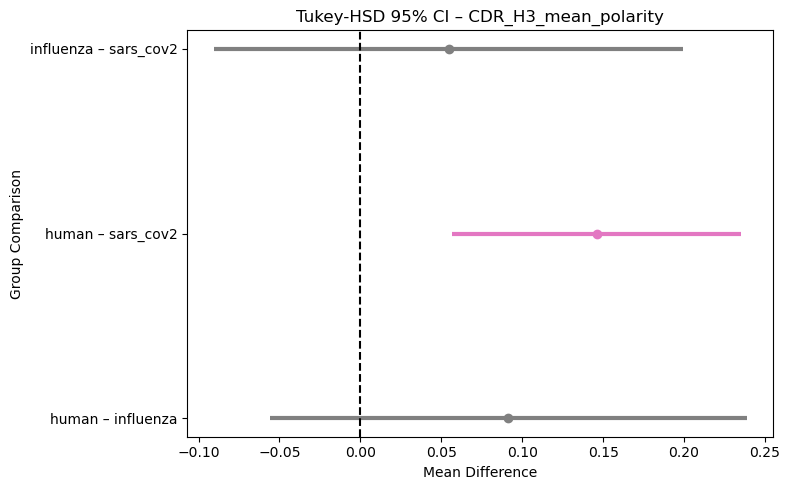

In [27]:
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H3_mean_polarity'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### CDR-H3 von humanen-Antikörper haben höhere Polarität im Schnitt
-----------

### CDR_H3_mean_charge
### Tukey HSD

In [28]:

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H3_mean_charge'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza   0.0068 0.8585 -0.0235   0.037  False
    human sars_cov2  -0.0266 0.0019 -0.0449 -0.0083   True
influenza sars_cov2  -0.0334 0.0233 -0.0632 -0.0036   True
----------------------------------------------------------


### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

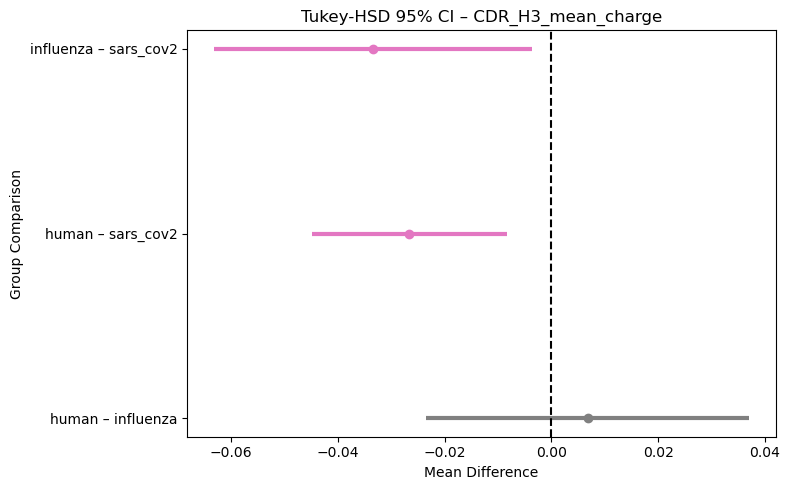

In [29]:


# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H3_mean_charge'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - mittlere Ladung in der CDR-H3-Region ist bei SARS-CoV-2-Antikörpern höher als bei humanen Antikörpern
#### - mittlere Ladung in CDR-H3-Region ist bei SARS-CoV-2-Antikörper höher als bei Influenza
#### => Antikörper gegen SARS-CoV-2 zeigen eine signifikant höhere mittlere Ladung in der CDR-H3-Region als Antikörper gegen Influenza oder aus der humanen Kontrollgruppe
------------

### CDR_H3_mean_mass
### Tukey HSD

In [30]:


# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H3_mean_mass'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza  -1.8956 0.1779    -4.4  0.6087  False
    human sars_cov2  -3.1731    0.0 -4.6895 -1.6568   True
influenza sars_cov2  -1.2775  0.444 -3.7438  1.1888  False
----------------------------------------------------------


### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

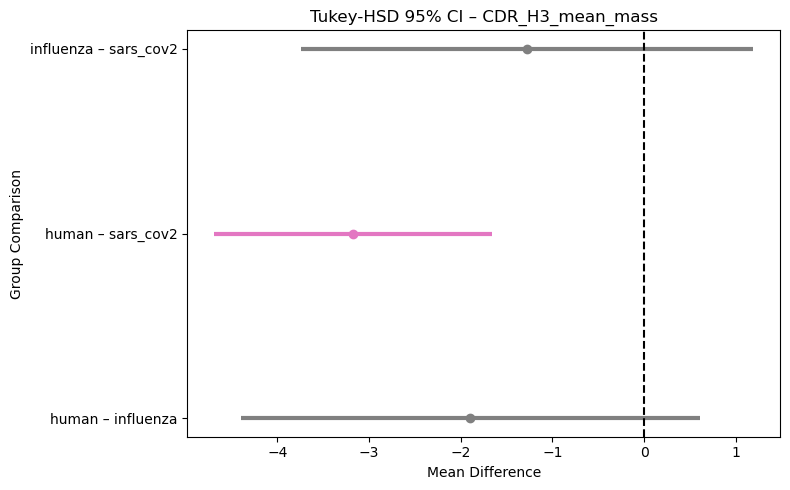

In [31]:


# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H3_mean_mass'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - Die mittlere Aminosäuremasse in CDR-H3 ist bei SARS-CoV-2-Antikörpern höher als bei humanen Antikörpern

--------


#### Erklärurng Plot

= Visualisierung **Tukey-HSD-Analyse** 

= **graphische Darstellung der Ergebnisse des Tukey-HSD-Tests** für die Variable `CDR_H3_mean_polarity`.

### Achsen & Bedeutung:

* **Y-Achse:** Paarweise Gruppenvergleiche 
* **X-Achse:** Mittelwertsdifferenz zwischen diesen Gruppen
* **Horizontale Linien:** 95 %-Konfidenzintervalle der Differenz
* **Punkte:** Der geschätzte Mittelwertsunterschied
* **Vertikale gestrichelte Linie:** Null-Linie (kein Unterschied)

### Farben:

* ** Rot:** Statistisch **signifikanter Unterschied** (p-Wert < 0.05)
* ** Grau:** Kein signifikanter Unterschied (p-Wert ≥ 0.05)

# ! Tukey-HSD-Test = Tukey’s Honest Significant Difference (HSD)

### = Post-hoc-Test
    = welche Gruppenpaare unterscheiden sich signifikant voneinander – welche Mittelwerte sind tatsächlich verschieden 

#### Verwendung

- bei signifikanten Unterschied: bei ANOVA p-Wert < 0,05

- bei mehrere Gruppen

- Um genau zu sehen, zwischen welchen Gruppen der Unterschied liegt

#### Wie funktioniert der Test:

- Differenz der Mittelwerte 

- Standardfehler der Differenz (berücksichtigt die Streuung innerhalb der Gruppen und die Anzahl der Stichproben (je größer n, desto genauer))

- Vergleich mit kritischem Wert
= Der kritische Wert stammt aus der studentisierten Range-Verteilung („q-Verteilung“) und hängt ab von:

- Anzahl der Gruppen k
- Anzahl aller Stichproben
- Signifikanzniveau α (meist 0.05)

#### Bedeutung

- meandiff: Mittelwertsunterschied

- p-adj: Adjustierter p-Wert

- lower / upper: Konfidenzintervall

- reject: True = signifikanter Unterschied
------------









### CDR H2
### ANOVA one way

In [32]:
# Load the dataset
df = pd.read_csv("all_data.tsv", sep="\t")

# Properties to be analyzed
properties = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass'] 

# Perform ANOVA test for each property (CDR_H2)
for prop in properties:
    column = f'CDR_H2_{prop}'
    
    # Extract groups
    group_human = df[df["source"] == "human"][column].dropna()
    group_sars = df[df["source"] == "sars_cov2"][column].dropna()
    group_influenza = df[df["source"] == "influenza"][column].dropna()
    
    # ANOVA test
    f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
    
    # Print result
    print(f"{column} – ANOVA p-value: {p_val:.4f}")


CDR_H2_mean_hydrophobicity – ANOVA p-value: 0.0015
CDR_H2_mean_charge – ANOVA p-value: 0.0019
CDR_H2_mean_polarity – ANOVA p-value: 0.1558
CDR_H2_mean_mass – ANOVA p-value: 0.0272


### to be investigated further : 

#### - CDR_H2_mean_hydrophobicity
#### - CDR_H2_mean_charge
#### - CDR_H2_mean_mass
------

### CDR_H2_mean_hydrophobicity
### Tukey HSD

In [33]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H2_mean_hydrophobicity'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
    human influenza   0.3527 0.0087  0.0735 0.6319   True
    human sars_cov2   0.2116 0.0095  0.0425 0.3806   True
influenza sars_cov2  -0.1411 0.4506 -0.4161 0.1339  False
---------------------------------------------------------


### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

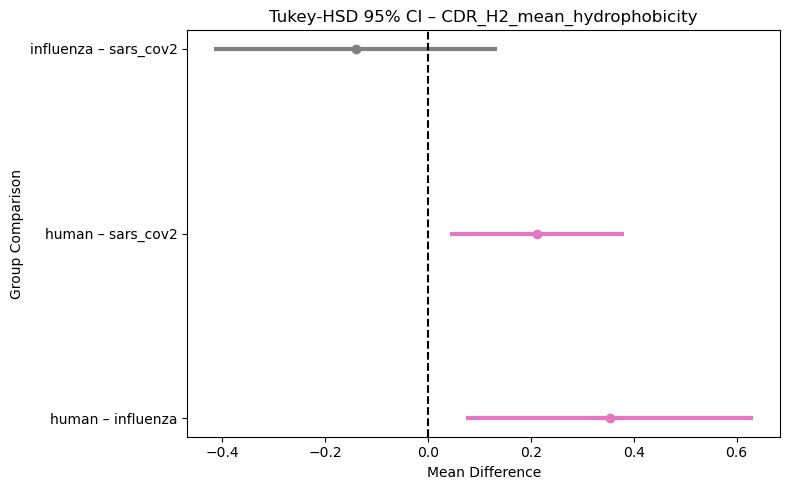

In [34]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H2_mean_hydrophobicity'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### Die CDR-H2-Regionen humaner Antikörper sind signifikant hydrophober als die von SARS-CoV-2- und Influenza-Antikörpern.
#### => deutet darauf hin, dass Antikörper gegen Viren eher weniger hydrophobe Sequenzmerkmale in der CDR-H2-Region aufweisen
-------------

### CDR_H2_mean_charge

In [48]:

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H2_mean_charge'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza   0.0539 0.0198  0.0069  0.1009   True
    human sars_cov2  -0.0158 0.3938 -0.0443  0.0127  False
influenza sars_cov2  -0.0697 0.0012  -0.116 -0.0234   True
----------------------------------------------------------


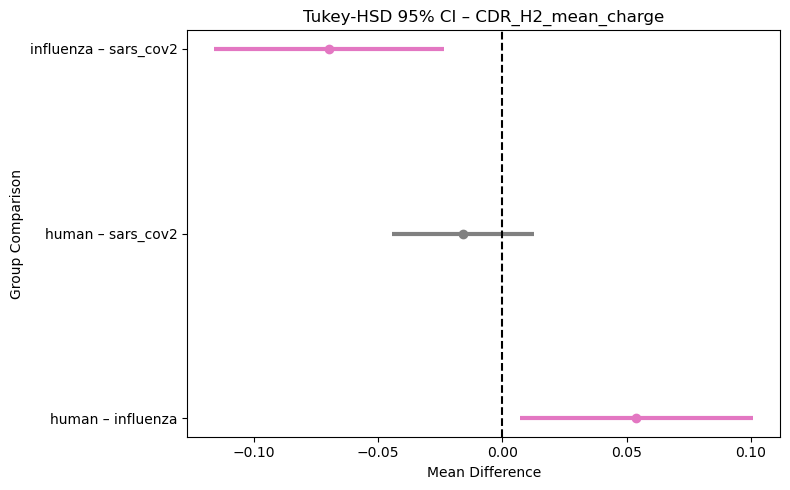

In [49]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H2_mean_charge'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


#### Interpretation:
#### - sars höher als influenza 
#### - human höher als influenza 
------

### CDR_H2_mean_mass
### TUKEY 

In [35]:

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H2_mean_mass'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)



   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza   0.5581 0.9354 -3.2064  4.3225  False
    human sars_cov2   -2.336 0.0431 -4.6153 -0.0567   True
influenza sars_cov2   -2.894 0.1596 -6.6013  0.8132  False
----------------------------------------------------------


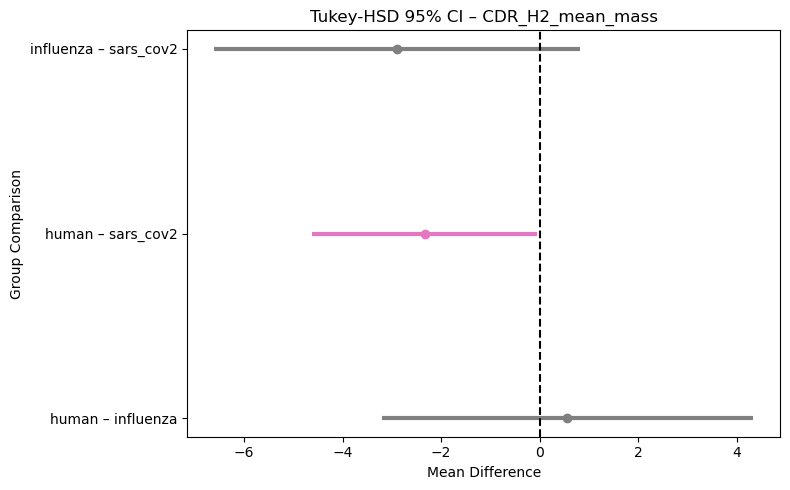

In [36]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H2_mean_mass'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
### - Sars cov größere mittlere Masse als Human

### CDR H1

In [37]:
# Load the combined dataset
df = pd.read_csv("all_data.tsv", sep="\t")

# Properties to be analyzed
properties = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass'] 

# Loop through each property (CDR_H1)
for prop in properties:
    column = f'CDR_H1_{prop}'
    
    # Extract groups
    group_human = df[df["source"] == "human"][column].dropna()
    group_sars = df[df["source"] == "sars_cov2"][column].dropna()
    group_influenza = df[df["source"] == "influenza"][column].dropna()
    
    # Perform ANOVA test
    f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
    
    # Print result
    print(f"{column} – ANOVA p-value: {p_val:.4f}")


CDR_H1_mean_hydrophobicity – ANOVA p-value: 0.0000
CDR_H1_mean_charge – ANOVA p-value: 0.3704
CDR_H1_mean_polarity – ANOVA p-value: 0.0000
CDR_H1_mean_mass – ANOVA p-value: 0.0000


### to be investigated further : 

#### - CDR_H1_mean_hydrophobicity, 
#### - CDR_H1_mean_polarity, 
#### - CDR_H1_mean_mass
------

### CDR_H1_mean_hydrophobicity
### Tukey HSD

In [38]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H1_mean_hydrophobicity'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza  -0.2621    0.0 -0.3972 -0.1271   True
    human sars_cov2   0.1391 0.0002  0.0574  0.2209   True
influenza sars_cov2   0.4013    0.0  0.2683  0.5343   True
----------------------------------------------------------


### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

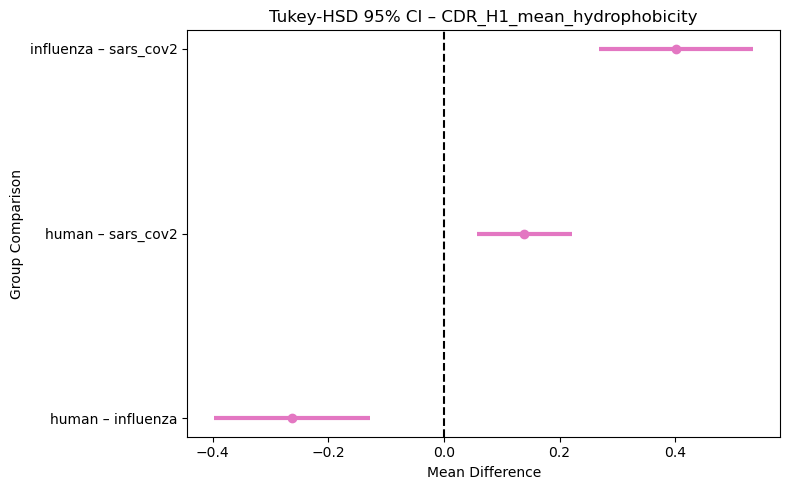

In [39]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H1_mean_hydrophobicity'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### -  Influenza-Antikörper stärker hydrophob als SARS-CoV-2
#### -  Human-Antikörper haben höhere Hydrophobizität als SARS-CoV-2
#### - Human-Antikörper haben niedrigere Hydrophobizität als Influenza-Antikörper
#### => Alle drei Gruppenunterschiede in der mittleren Hydrophobizität der CDR-H1-Region sind signifikant. Influenza-Antikörper sind am hydrophobsten, SARS-CoV-2-Antikörper am wenigsten hydrophob, und humane Antikörper liegen dazwischen
----------

### CDR_H1_mean_polarity
### Tukey HSD

In [40]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H1_mean_polarity'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza   0.4239    0.0  0.2792  0.5687   True
    human sars_cov2    0.032 0.6683 -0.0557  0.1196  False
influenza sars_cov2   -0.392    0.0 -0.5345 -0.2494   True
----------------------------------------------------------


### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

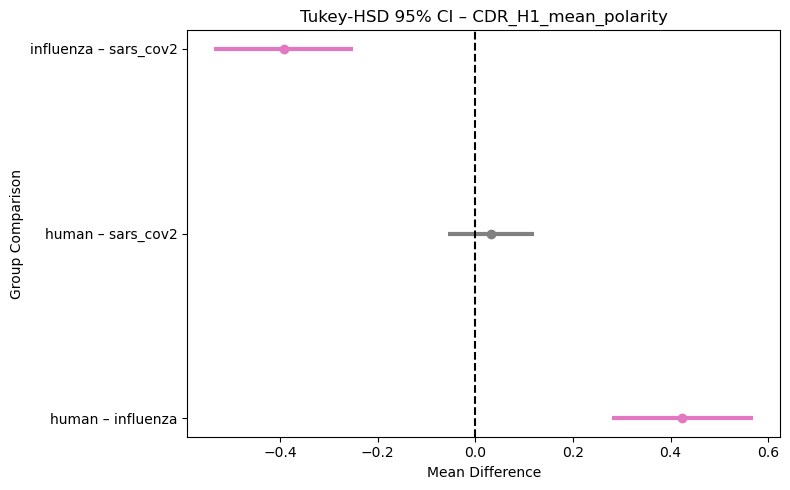

In [41]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H1_mean_polarity'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - Influenza-Antikörper haben niedrigere Polarität als SARS-CoV-2
#### - Human-Antikörper haben höhere Polarität als Influenza
--------

### CDR_H1_mean_mass
### Tukey HSD

In [42]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H1_mean_mass'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza  -6.6346    0.0 -9.2088 -4.0604   True
    human sars_cov2  -3.3844    0.0  -4.943 -1.8258   True
influenza sars_cov2   3.2501 0.0076  0.7151  5.7852   True
----------------------------------------------------------


### Visualisierung der Gruppenunterschiede mit dem Tukey-HSD-Test

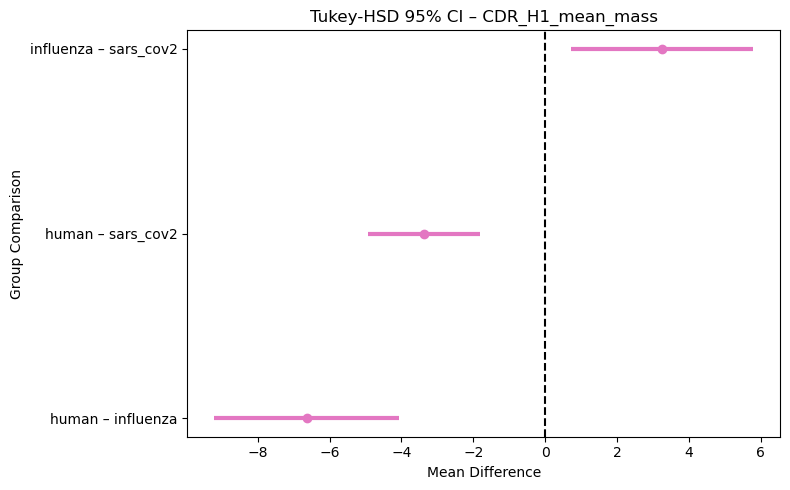

In [43]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H1_mean_mass'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - Die mittlere Masse bei human-Antikörpern ist signifikant geringer als bei SARS-CoV-2-Antikörpern
#### - Die mittlere Masse der CDR_H1-Region ist bei human-Antikörpern deutlich geringer als bei Influenza-Antikörpern
#### => Die mittlere Masse der CDR_H1-Region ist bei human-Antikörpern signifikant geringer als bei Antikörpern gegen Influenza oder SARS-CoV-2
-------

# Compare lengths

In [44]:
## ANOVA Test
# TSV-Datei einlesen
df = pd.read_csv("all_data.tsv", sep="\t")

# Liste der Längen-Spalten
length_columns = ['cdr_h1_length', 'cdr_h2_length', 'cdr_h3_length']

# Schleife über alle Regionen
for region in length_columns:
    group_human = df[df["source"] == "human"][region].dropna()
    group_sars = df[df["source"] == "sars_cov2"][region].dropna()
    group_influenza = df[df["source"] == "influenza"][region].dropna()
    
    f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
    print(f"{region} – ANOVA p-value: {p_val:.4f}")



cdr_h1_length – ANOVA p-value: 0.0000
cdr_h2_length – ANOVA p-value: 0.0000
cdr_h3_length – ANOVA p-value: 0.0000


### CDR H1

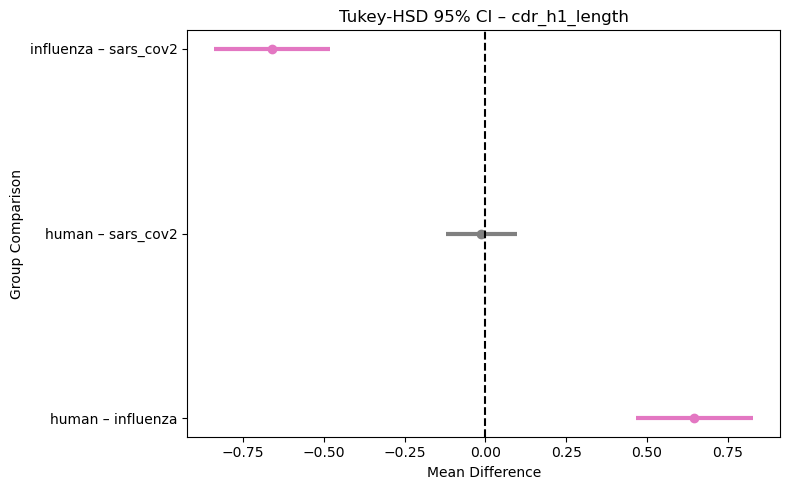

In [45]:
# Tukey-HSD für CDR-H1-Länge
column = "cdr_h1_length"
df_clean = df[[column, "source"]].dropna()

tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)

# In DataFrame umwandeln
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)
summary_df["color"] = summary_df["reject"].apply(lambda x: "tab:pink" if x else "gray")

# Plot
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - CDR-H1 ist bei human-Antikörpern länger als bei Influenza
#### - Influenza-Antikörper haben kürzere CDR-H1-Regionen als SARS-CoV-2-Antikörper
#### => Die CDR-H1-Region von Influenza-Antikörpern ist sowohl in human- als auch in SARS-CoV-2-Antikörpern signifikant kürzer
-----------

### CDR H2

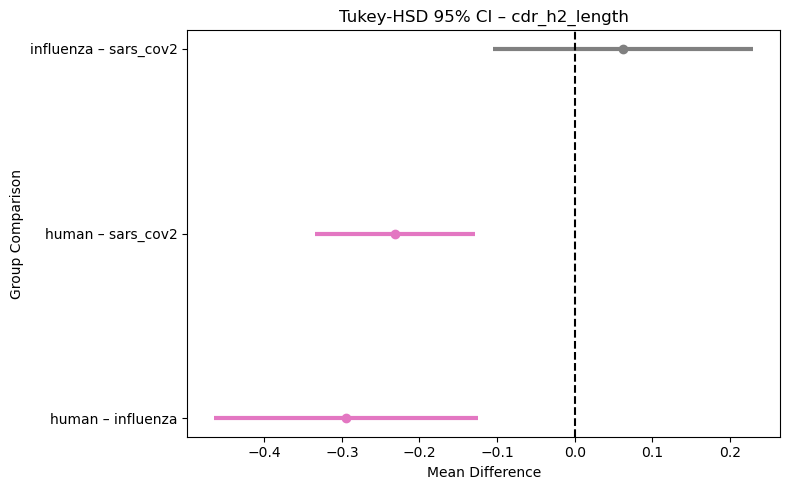

In [46]:

# Tukey-HSD für CDR-H2-Länge
column = "cdr_h2_length"
df_clean = df[[column, "source"]].dropna()

tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)

# In DataFrame umwandeln
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)
summary_df["color"] = summary_df["reject"].apply(lambda x: "tab:pink" if x else "gray")

# Plot
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - CDR-H2-Länge ist bei SARS-CoV-2-Antikörpern länger als bei human-Antikörpern
#### - CDR-H2-Länge in Influenza länger als bei human
#### => Die mittlere CDR-H2-Länge ist in human-Antikörpern signifikant kürzer als in SARS-CoV-2- und Influenza-Antikörpern.
-----------

## CDR H3 

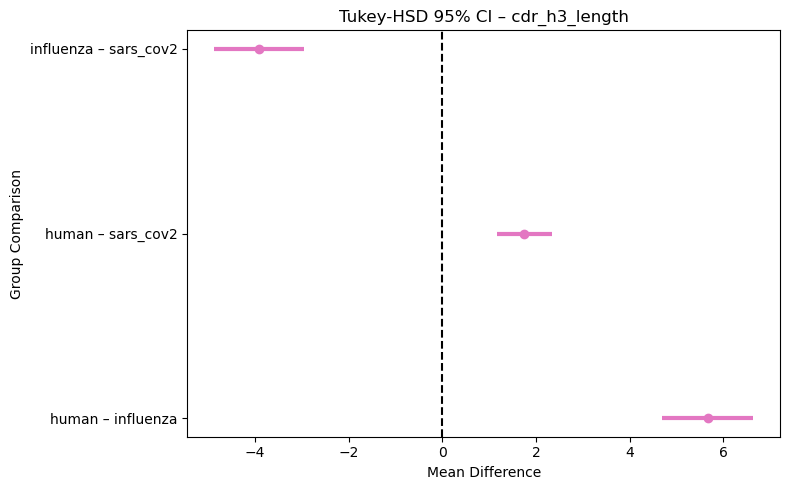

In [47]:

# Tukey-HSD für CDR-H3-Länge
column = "cdr_h3_length"
df_clean = df[[column, "source"]].dropna()

tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)

# In DataFrame umwandeln
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)
summary_df["color"] = summary_df["reject"].apply(lambda x: "tab:pink" if x else "gray")

# Plot
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - cdr_h3_length ist bei SARS-CoV-2 signifikant länger als bei Influenza
#### - cdr_h3_length ist bei SARS-CoV-2 signifikant kürzer als bei Human
#### - cdr_h3_length ist bei Human signifikant länger als bei Influenza
#### => influenza < sars_cov2 < human
---------